# Reflection FWI · where the velocity gradient comes from

For reflection waveform inversion (RWI) the velocity gradient splits into four terms
(Wu & Alkhalifah, 2015, eq. 15–17):

$$\frac{\partial J}{\partial v} = \underbrace{\mathrm{I}}_{\text{transmission}}
  + \underbrace{\mathrm{II}+\mathrm{III}+\mathrm{IV}}_{\text{reflection}},\qquad
  \frac{\partial J}{\partial w} = \mathrm{I}.$$

In sweep those two halves come from **two different equations**, and this notebook plots them
side by side:

| solver | receiver field | gradient it produces | sensitivity |
|---|---|---|---|
| `Acoustic` | `h1` (background $p$) | **I** $=\langle\lambda, B'(v)p\rangle$ | direct / diving waves |
| `AcousticLSRTM` | `sh1` (scattered $q$) | **II+III+IV** | reflection wavepath + image point |

`AcousticLSRTM` is a two-field Born engine: a background field `h1` plus a scattered field
`sh1` driven by the reflectivity coupling $w\,v^2\nabla^2 h1$. Because $v$ enters that step in
**three** places (background propagation → IV, scattered propagation → II, scattered source →
III) its gradient carries three terms, while `Acoustic` — where $v$ enters once — carries one.

The two halves are complementary, but only when they share **one residual**: we therefore run
both solvers in a single objective and give each its own autograd leaf for $v$, so one
`backward()` separates I from II+III+IV without any hand-written adjoint.

> Wu, Z. & Alkhalifah, T. (2015). *Simultaneous inversion of the background velocity and the
> perturbation in full-waveform inversion.* Geophysics **80**(6), R317–R329.

## 1. Setup — the paper's two-layer experiment

In [1]:
import sys, pathlib

_repo = pathlib.Path().resolve().parents[1]     # docs/notebooks/ -> repo root
if str(_repo / "src") not in sys.path:
    sys.path.insert(0, str(_repo / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic, AcousticLSRTM
from sweep.propagator.torch import PropTorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
# Wu & Alkhalifah (2015) Figure 1 geometry: 2000 m/s over 3000 m/s, flat reflector at 5 km,
# one source at 2.5 km and one receiver at 12.5 km on the surface.
dh, (nz, nx) = 40.0, (175, 375)                   # 7 km deep x 15 km wide
iface = int(5000 / dh)
src_x, rec_x = int(2500 / dh), int(12500 / dh)

vp = np.full((nz, nx), 2000.0, np.float32); vp[iface:] = 3000.0
w  = np.zeros((nz, nx), np.float32);         w[iface]  = 0.05     # reflectivity on the interface

order, abcn = 8, 30      # 8th order in space: see the dispersion note below
dt, nt, fm, delay = 0.004, 2000, 6.0, 0.20        # 8 s record, 6 Hz Ricker

def ricker(nt, dt, fm, delay):
    t = np.arange(nt) * dt - delay
    a = (np.pi * fm * t) ** 2
    return ((1 - 2 * a) * np.exp(-a)).astype(np.float32)

wave = torch.tensor(ricker(nt, dt, fm, delay), device=device)
src  = np.array([[src_x, 1]], np.int32)
rec  = np.array([[[rec_x, 1]]], np.int32)
extent = [0, nx * dh / 1000, nz * dh / 1000, 0]

**A note on the grid.** A 6 Hz Ricker still carries useful energy out to roughly
$2.5 f_m \approx 15$ Hz, where the shortest wavelength is $2000/15 \approx 133$ m — only
$133/40 \approx 3.3$ points per wavelength on this 40 m grid. That is below the ~5 ppw a
4th-order stencil wants, and a 4th-order run shows it: fine ripples trail the outer arcs of the
gradient. Going to **8th order** costs almost nothing here and brings the result much closer to a
twice-refined reference (interior $\cos$ 0.95 → 0.99), which is why `order = 8` above. Refining
`dh` instead would work too, at ~8x the cost (4x the cells and half the time step).

## 2. One objective, two solvers

`Acoustic` records the background field, `AcousticLSRTM` the scattered field, and the modelled
data is their sum $\mathcal C(p+q)$. Both run on the compiled `c` backend in **full (store-all)**
mode, which is the mode that computes the LSRTM tomographic `vp` gradient on this branch.

Giving the two solvers **separate `vp` leaves** with the *same* loss is what isolates the terms:
one `backward()` writes I into `vp_ac.grad` and II+III+IV into `vp_ls.grad`, both driven by the
identical residual. (Running the solvers in separate losses would differentiate two *different*
objectives and the halves would no longer add up.)

In [3]:
def build(equation_cls, receiver):
    eq = equation_cls(spatial_order=order, device=device, backend="torch")
    return PropTorch(eq, shape=(nz, nx), dev=device, dh=dh, dt=dt, nt=nt, B=1,
                     source_type=["h1"], receiver_type=[receiver], abcn=abcn,
                     free_surface=False, pml_type="cpmlr", backend="torch",
                     impl="c", use_ckpt=False,
                     boundary_saving_config={"enabled": True})   # bs (low memory)

def split_gradients():
    """One loss, two vp leaves -> (term I, terms II+III+IV) under the SAME residual."""
    vp_ac = torch.tensor(vp, device=device, requires_grad=True)   # sees Acoustic only
    vp_ls = torch.tensor(vp, device=device, requires_grad=True)   # sees LSRTM only
    ref   = torch.tensor(w,  device=device, requires_grad=True)
    Cp = build(Acoustic,      "h1")(wave, src, rec, models=[vp_ac])
    Cq = build(AcousticLSRTM, "sh1")(wave, src, rec, models=[vp_ls, ref])
    loss = 0.5 * ((Cp + Cq) ** 2).sum()        # obs = 0 -> residual = the modelled data
    loss.backward()
    return vp_ac.grad.cpu().numpy(), vp_ls.grad.cpu().numpy(), ref.grad.cpu().numpy()

g_I, g_refl, g_m = split_gradients()            # I  |  II+III+IV  |  dJ/dm
g_total = g_I + g_refl
print(f"dJ/dvp  Acoustic       |I|         = {np.linalg.norm(g_I):.3e}")
print(f"dJ/dvp  AcousticLSRTM  |II+III+IV| = {np.linalg.norm(g_refl):.3e}"
      f"   ({100*np.linalg.norm(g_refl)/np.linalg.norm(g_I):.1f}% of |I|)")
print(f"dJ/dm   AcousticLSRTM  |dJ/dm|     = {np.linalg.norm(g_m):.3e}")

# Paper eq. 15 says dJ/dw = I.  sweep's `m` is a dimensionless reflectivity while the paper's `w`
# is a velocity perturbation, so the two differ by exactly 2/v -- check it.
cosang = lambda a, b: float(a.ravel() @ b.ravel() / (np.linalg.norm(a) * np.linalg.norm(b)))
print("")
print(f"check  dJ/dm * (2/v)  vs  I :  cos = {cosang(g_I, (2.0 / vp) * g_m):.6f}"
      f"   amplitude ratio = {np.linalg.norm(g_I) / np.linalg.norm((2.0 / vp) * g_m):.4f}")

# Both halves must be non-zero: a mode that silently returns a zero vp gradient would make
# every comparison below pass trivially (0 == 0).
assert np.linalg.norm(g_I) > 1e-20, "term I is zero"
assert np.linalg.norm(g_refl) > 1e-20, "II+III+IV is zero -- this memory mode has no LSRTM vp gradient"

dJ/dvp  Acoustic       |I|         = 3.827e-03
dJ/dvp  AcousticLSRTM  |II+III+IV| = 7.597e-05   (2.0% of |I|)
dJ/dm   AcousticLSRTM  |dJ/dm|     = 3.828e+00

check  dJ/dm * (2/v)  vs  I :  cos = 1.000000   amplitude ratio = 1.0000


### The halves really do add up

With a **single shared** `vp` leaf the same objective gives the complete $\partial J/\partial v$
directly. It must equal the sum of the two halves above — that is the check that the split is a
decomposition and not two unrelated gradients.

In [4]:
def joint_gradient():
    """Both solvers on ONE vp leaf -> the complete dJ/dv = I+II+III+IV."""
    vp_j = torch.tensor(vp, device=device, requires_grad=True)
    ref  = torch.tensor(w,  device=device, requires_grad=True)
    Cp = build(Acoustic,      "h1")(wave, src, rec, models=[vp_j])
    Cq = build(AcousticLSRTM, "sh1")(wave, src, rec, models=[vp_j, ref])
    (0.5 * ((Cp + Cq) ** 2).sum()).backward()
    return vp_j.grad.cpu().numpy()

g_joint = joint_gradient()
rel = np.linalg.norm(g_joint - g_total) / np.linalg.norm(g_joint)
cos = float(g_joint.ravel() @ g_total.ravel() /
            (np.linalg.norm(g_joint) * np.linalg.norm(g_total)))
print(f"I + (II+III+IV)  vs  joint dJ/dv :  cos = {cos:.6f}   rel = {rel:.2e}")

I + (II+III+IV)  vs  joint dJ/dv :  cos = 1.000000   rel = 0.00e+00


## 3. The two sensitivities, side by side

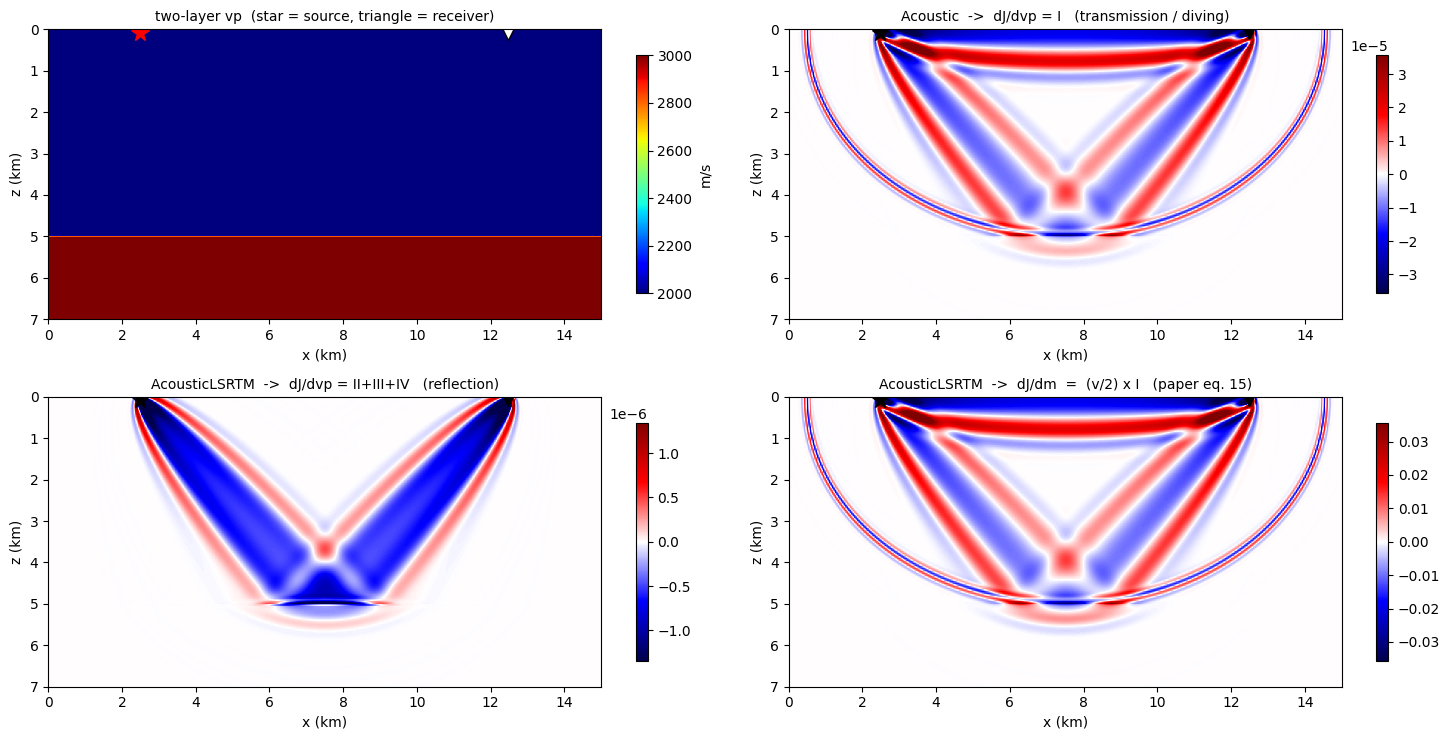

In [5]:
def panel(ax, field, title, ref=None, cmap="seismic"):
    clip = np.percentile(np.abs(field if ref is None else ref), 99.5)
    im = ax.imshow(field, extent=extent, aspect="auto", vmin=-clip, vmax=clip, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x (km)"); ax.set_ylabel("z (km)")
    ax.plot(src_x * dh / 1000, 0.08, "k*", ms=12)
    ax.plot(rec_x * dh / 1000, 0.08, "kv", ms=9)
    return im

fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
im = ax[0, 0].imshow(vp, extent=extent, aspect="auto", cmap="jet")
ax[0, 0].set_title("two-layer vp  (star = source, triangle = receiver)", fontsize=10)
ax[0, 0].set_xlabel("x (km)"); ax[0, 0].set_ylabel("z (km)")
ax[0, 0].plot(src_x * dh / 1000, 0.08, "r*", ms=13)
ax[0, 0].plot(rec_x * dh / 1000, 0.08, "wv", ms=10, mec="k")
fig.colorbar(im, ax=ax[0, 0], shrink=0.82, label="m/s")

for a, (f, t, r) in zip(ax.ravel()[1:], [
        (g_I,     "Acoustic  ->  dJ/dvp = I   (transmission / diving)", None),
        (g_refl,  "AcousticLSRTM  ->  dJ/dvp = II+III+IV   (reflection)", None),
        (g_m,     "AcousticLSRTM  ->  dJ/dm  =  (v/2) x I   (paper eq. 15)",  None)]):
    fig.colorbar(panel(a, f, t, r), ax=a, shrink=0.82)
fig.tight_layout()

Reading the panels:

- **`Acoustic` → $\partial J/\partial v_p$ = I** is the standard-FWI kernel: broad transmission
  arcs sweeping from source to receiver. It *also* carries a reflection response at 5 km — the
  interface is a genuine velocity contrast inside `vp`, so the background field reflects off it too.
- **`AcousticLSRTM` → $\partial J/\partial v_p$ = II+III+IV** is the reflection sensitivity
  *generated by the reflectivity model* `m`: the two "rabbit ear" wavepaths running
  source → reflector → receiver, plus the localized image-point response at 5 km depth (term III,
  the singular part the paper weights with $\beta$). The direct/diving arcs are absent — this is
  the low-wavenumber update RWI adds where diving waves never reach, and it is exactly the anatomy
  of the paper's Figure 1, which is plotted from the scattered data alone.
- **`AcousticLSRTM` → $\partial J/\partial m$** looks like the first panel *because it is the same
  field*: the paper's eq. 15 states $\partial J/\partial w = \mathrm{I}$, and the check printed
  above confirms it here to $\cos = 1.000000$ once the parameterization factor is removed
  ($m$ is a dimensionless reflectivity, the paper's $w$ a velocity perturbation — exactly $2/v$
  apart, hence the ~1000x magnitude gap). Both are the correlation of the same adjoint with the
  same background field.

So this problem really carries **two** distinct sensitivities, not three: the transmission kernel
$\mathrm{I}$ (which doubles as the reflectivity update) and the reflection kernel
$\mathrm{II{+}III{+}IV}$.

**Why the total $\partial J/\partial v_p = \mathrm{I}+\mathrm{II}+\mathrm{III}+\mathrm{IV}$ is not
plotted:** with this geometry the reflection half is only ~2 % of term I (printed above), so the
sum is visually indistinguishable from the first gradient panel. The scattered field is linear in
`m`, and here `m = 0.05` on a single-cell reflector. That imbalance is precisely why the paper
plots II+III+IV alone in Figure 1, and why RWI carries the weights $\alpha$ (whole gradient) and
$\beta$ (term III) to rebalance the two contributions.

## 4. Which memory modes give the LSRTM `vp` gradient?

The tomographic `vp` gradient of `AcousticLSRTM` is available in:

| mode | how | `vp` gradient |
|---|---|---|
| **bs** (`{"enabled": True}`, used here) | boundary-saves **both** fields and reconstructs them | yes (low memory) |
| **full** (`{"enabled": False}`) | store every wavefield | yes |
| ckpt / recursive_ckpt | background-only replay | no — `vp.grad` is 0 |

Prefer **bs**: it matches full to float32 roundoff (`cos = 1.000000`) at a fraction of the memory,
which is what makes an RWI loop practical. The checkpointing modes replay the background field
only, so terms II/III/IV have nothing to correlate against and `vp.grad` comes back zero — the
`assert` in section 2 is there to catch exactly that. The `ref` (reflectivity) gradient is correct
in every mode. For a full RWI loop, alternate updates of the background
`v` (from the terms above) and the perturbation `w` (from `ref.grad`).